# Detecção de Cartas de Baralho com YOLOv8
**Disciplina:** Ciência de Dados — Deep Learning  
**Dataset:** Playing Cards (Roboflow Universe — Augmented Startups)  
**Tarefa:** Detectar e classificar as 52 cartas de um baralho em imagens  
**Justificativa:** Nenhuma das 52 classes (ex: `AS`, `KH`, `10C`) faz parte das 80 classes do COCO.

## 1. Instalação de Dependências

In [1]:
# Instala as bibliotecas necessárias
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics", "roboflow", "--quiet"])

import ultralytics
ultralytics.checks()

Ultralytics 8.4.66  Python-3.13.5 torch-2.12.0+cpu CPU (Intel Core i5-10400F 2.90GHz)
Setup complete  (12 CPUs, 15.9 GB RAM, 861.3/953.1 GB disk)


## 2. Importações

In [2]:
import os
import glob
import random
import yaml
import gc
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
from ultralytics import YOLO

# Diretório base do projeto (pasta onde este notebook está)
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
print("Diretório base:", BASE_DIR)
print("Dispositivo disponível:", "GPU (CUDA)" if torch.cuda.is_available() else "CPU")

Diretório base: c:\Users\luana\Cartas-de-Baralho
Dispositivo disponível: CPU


## 3. Download do Dataset

O dataset **Playing Cards** está disponível publicamente no Roboflow Universe.  
Contém **10.100 imagens** sintéticas de cartas sobre diferentes fundos,  
com **52 classes** (uma por carta: 2C, 3H, AS, KD etc.).  
Divisão padrão: **train / valid / test**.

In [3]:
from roboflow import Roboflow

# Caminho onde o dataset será salvo localmente
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
os.makedirs(DATASET_DIR, exist_ok=True)

# Verifica se o dataset já foi baixado anteriormente
YAML_PATH = os.path.join(DATASET_DIR, "Playing-Cards-4", "data.yaml")

if not os.path.exists(YAML_PATH):
    print("Baixando dataset do Roboflow...")
    rf = Roboflow(api_key="MtcfouLs1yuD9KRc0fEN")
    project = rf.workspace("augmented-startups").project("playing-cards-ow27d")
    version = project.version(4)

    # Muda para o diretório dataset antes de baixar
    original_dir = os.getcwd()
    os.chdir(DATASET_DIR)
    dataset = version.download("yolov8")
    os.chdir(original_dir)

    DATASET_PATH = os.path.join(DATASET_DIR, os.path.basename(dataset.location))
    YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")
    print("Dataset baixado em:", DATASET_PATH)
else:
    DATASET_PATH = os.path.dirname(YAML_PATH)
    print("Dataset já existe em:", DATASET_PATH)

print("YAML:", YAML_PATH)

Baixando dataset do Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Playing-Cards-4 in yolov8:: 100%|██████████| 48478/48478 [00:23<00:00, 2036.73it/s]


Dataset baixado em: c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4
YAML: c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\data.yaml


## 4. Análise Exploratória do Dataset (EDA)

Antes de treinar, vamos inspecionar 6 imagens do conjunto de treino com suas bounding boxes anotadas.

In [4]:
# Ler classes do YAML
with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]
print(f"Número de classes: {len(class_names)}")
print("Primeiras 10 classes:", class_names[:10])

# Contar imagens por split
for split in ["train", "valid", "test"]:
    split_dir = os.path.join(DATASET_PATH, split, "images")
    if os.path.exists(split_dir):
        n = len([f for f in os.listdir(split_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))])
        print(f"  {split}: {n} imagens")

Número de classes: 52
Primeiras 10 classes: ['10C', '10D', '10H', '10S', '2C', '2D', '2H', '2S', '3C', '3D']
  train: 21203 imagens
  valid: 2020 imagens
  test: 1010 imagens


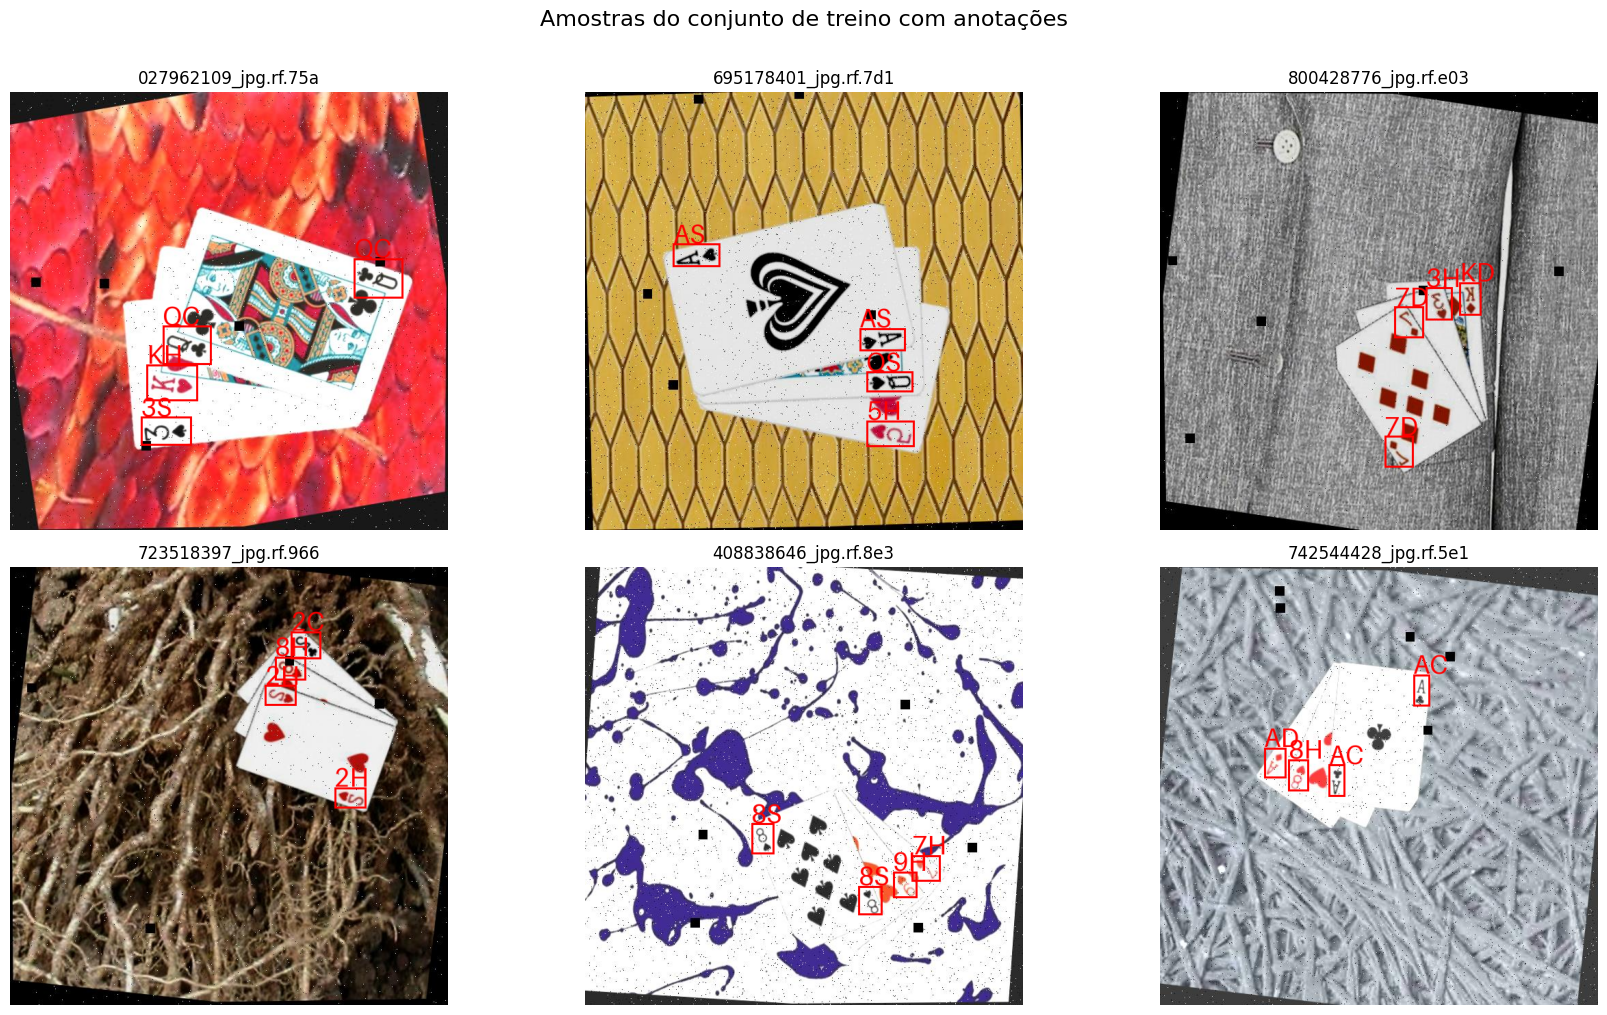

In [5]:
# Visualizar 6 imagens de treino com bounding boxes anotadas
train_img_dir   = os.path.join(DATASET_PATH, "train", "images")
train_label_dir = os.path.join(DATASET_PATH, "train", "labels")

all_imgs = [f for f in os.listdir(train_img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
sample   = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_file in zip(axes, sample):
    img_path   = os.path.join(train_img_dir, img_file)
    label_path = os.path.join(train_label_dir, os.path.splitext(img_file)[0] + ".txt")

    img  = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size

    if os.path.exists(label_path):
        with open(label_path) as lf:
            for line in lf:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                x2 = (xc + bw / 2) * w
                y2 = (yc + bh / 2) * h
                draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                label = class_names[cid] if cid < len(class_names) else str(cid)
                fs = max(int(w * 0.06), 12)
                draw.text((x1, max(y1 - fs, 0)), label, fill="red", font_size=fs)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_file[:20])

plt.suptitle("Amostras do conjunto de treino com anotações", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 5. Liberação de Memória

In [6]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Memória GPU liberada.")
else:
    print("Executando em CPU — sem VRAM para liberar.")

Executando em CPU — sem VRAM para liberar.


## 6. Treinamento do Modelo YOLOv8

**Modelo base:** `yolov8n.pt` (nano) — mais leve para rodar localmente sem GPU.  
Use `yolov8m.pt` se tiver GPU disponível.

**Hiperparâmetros configurados:**

| Parâmetro   | Valor (CPU) | Valor (GPU) | Justificativa |
|-------------|-------------|-------------|---------------|
| `epochs`    | 20          | 50          | Equilíbrio entre convergência e tempo |
| `imgsz`     | 320         | 640         | 320px = 4× mais rápido que 640px no CPU |
| `batch`     | 16          | 32          | Batch maior compensa imagens menores |
| `fraction`  | 0.3         | 1.0         | 30% do treino (~6.300 imgs) suficiente no CPU |
| `cache`     | True        | True        | Carrega imagens na RAM, elimina I/O de disco |
| `lr0`       | 0.01        | 0.01        | Taxa de aprendizado inicial padrão |
| `optimizer` | SGD         | SGD         | Robusto para detecção de objetos |
| `patience`  | 10          | 15          | Early stopping para evitar overfitting |

In [7]:
# Detecta automaticamente GPU ou CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Treinando em: {DEVICE}")

# Ajusta hiperparâmetros conforme dispositivo
MODEL_NAME = "yolov8n.pt" if DEVICE == "cpu" else "yolov8m.pt"
EPOCHS     = 20           if DEVICE == "cpu" else 50
BATCH      = 16           if DEVICE == "cpu" else 32
IMGSZ      = 320          if DEVICE == "cpu" else 640
FRACTION   = 0.3          if DEVICE == "cpu" else 1.0

print(f"  Modelo:   {MODEL_NAME}")
print(f"  Épocas:   {EPOCHS}")
print(f"  imgsz:    {IMGSZ}  (menor = mais rápido no CPU)")
print(f"  Fração:   {FRACTION*100:.0f}% do dataset de treino")

# Carregar modelo pré-treinado (transfer learning do COCO)
model = YOLO(MODEL_NAME)

# Treinar no dataset de cartas de baralho
results_train = model.train(
    data      = YAML_PATH,
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    fraction  = FRACTION,
    cache     = True,
    lr0       = 0.01,
    optimizer = "SGD",
    patience  = 10,
    project   = os.path.join(BASE_DIR, "runs", "detect"),
    name      = "playing_cards",
    exist_ok  = True,
    device    = DEVICE,
    verbose   = True,
)

print("\nTreinamento concluído!")
print("Modelo salvo em:", model.trainer.save_dir)

Treinando em: cpu
  Modelo:   yolov8n.pt
  Épocas:   20
  imgsz:    320  (menor = mais rápido no CPU)
  Fração:   30% do dataset de treino
New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.13.5 torch-2.12.0+cpu CPU (Intel Core i5-10400F 2.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.3, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, kera

KeyboardInterrupt: 

In [8]:
# Salva o caminho do modelo treinado para uso nas próximas células
SAVE_DIR    = model.trainer.save_dir
BEST_WEIGHTS = os.path.join(SAVE_DIR, "weights", "best.pt")
print("Melhor modelo salvo em:", BEST_WEIGHTS)

Melhor modelo salvo em: C:\Users\luana\Cartas-de-Baralho\runs\detect\playing_cards\weights\best.pt


In [9]:
# ---- OPCIONAL: Carregar pesos já treinados (pule se acabou de treinar) ----
# BEST_WEIGHTS = os.path.join(BASE_DIR, "runs", "detect", "playing_cards", "weights", "best.pt")
# SAVE_DIR     = os.path.dirname(os.path.dirname(BEST_WEIGHTS))
# model = YOLO(BEST_WEIGHTS)
# print("Modelo carregado de:", BEST_WEIGHTS)

## 7. Visualização do Data Augmentation

O YOLOv8 aplica automaticamente aumentações de dados (mosaic, flip, HSV jitter, etc.)  
para melhorar a generalização. Veja um lote de treino aumentado abaixo.

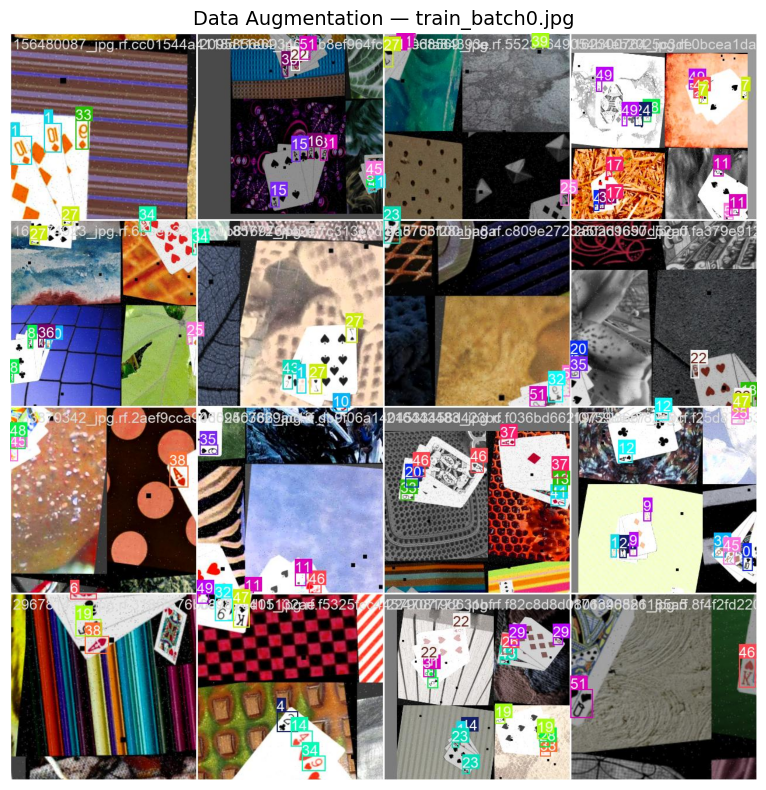

In [10]:
aug_path = os.path.join(SAVE_DIR, "train_batch0.jpg")

if os.path.exists(aug_path):
    img = Image.open(aug_path)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Data Augmentation — train_batch0.jpg", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Imagem de lote não encontrada em '{aug_path}'.")
    print("Normal se o treinamento foi pulado e o modelo foi carregado diretamente.")

## 8. Avaliação no Conjunto de Teste

Métricas calculadas:
- **Precision (P):** Fração das detecções corretas dentre todas as detectadas.
- **Recall (R):** Fração das instâncias corretas detectadas dentre todas as reais.
- **mAP@0.5:** mAP com IoU threshold 0.5 (métrica principal).
- **mAP@0.5:0.95:** mAP médio de IoU 0.5 a 0.95 (métrica mais rigorosa, padrão COCO).

In [12]:
# Avaliação no split de teste com os melhores pesos
model_eval = YOLO(BEST_WEIGHTS)
val_results = model_eval.val(data=YAML_PATH, split="test")

metrics = val_results.results_dict
print("=" * 45)
print(f"  Precisão  (Precision):  {metrics.get('metrics/precision(B)', 0):.4f}")
print(f"  Revocação (Recall):     {metrics.get('metrics/recall(B)',    0):.4f}")
print(f"  mAP@0.5:                {metrics.get('metrics/mAP50(B)',     0):.4f}")
print(f"  mAP@0.5:0.95:           {metrics.get('metrics/mAP50-95(B)', 0):.4f}")
print("=" * 45)

Ultralytics 8.4.66  Python-3.13.5 torch-2.12.0+cpu CPU (Intel Core i5-10400F 2.90GHz)
Model summary (fused): 73 layers, 3,015,788 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 135.825.0 MB/s, size: 50.0 KB)
val: Scanning C:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\labels... 1010 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1010/1010 2.1Kit/s 0.5s1ss
val: New cache created: C:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 2.5it/s 25.3s0.4ss
                   all       1010       4040      0.951      0.938      0.984      0.758
                   10C         53         77       0.99      0.974      0.991      0.796
                   10D         53         74      0.926          1      0.995      0.775
                   10H         41         54      0.989      0.981      0.994      0.7

## 9. Curvas de Treinamento

Os gráficos abaixo mostram a evolução das métricas ao longo das épocas.

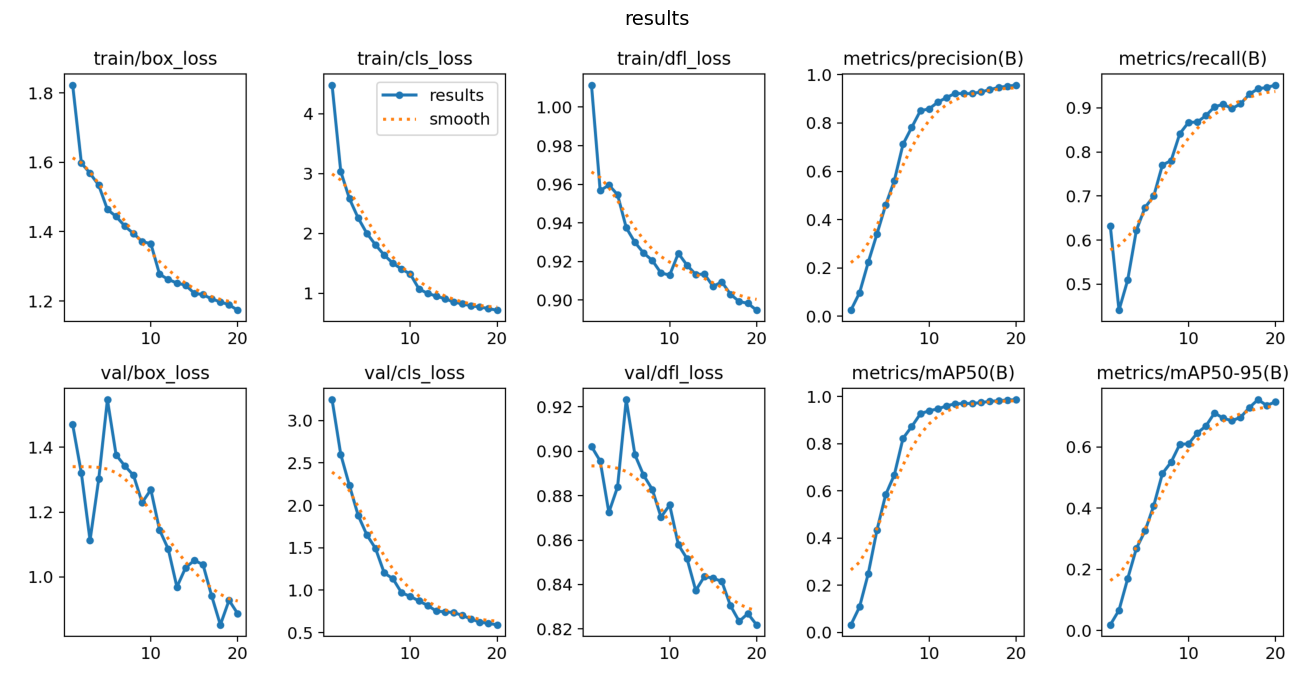

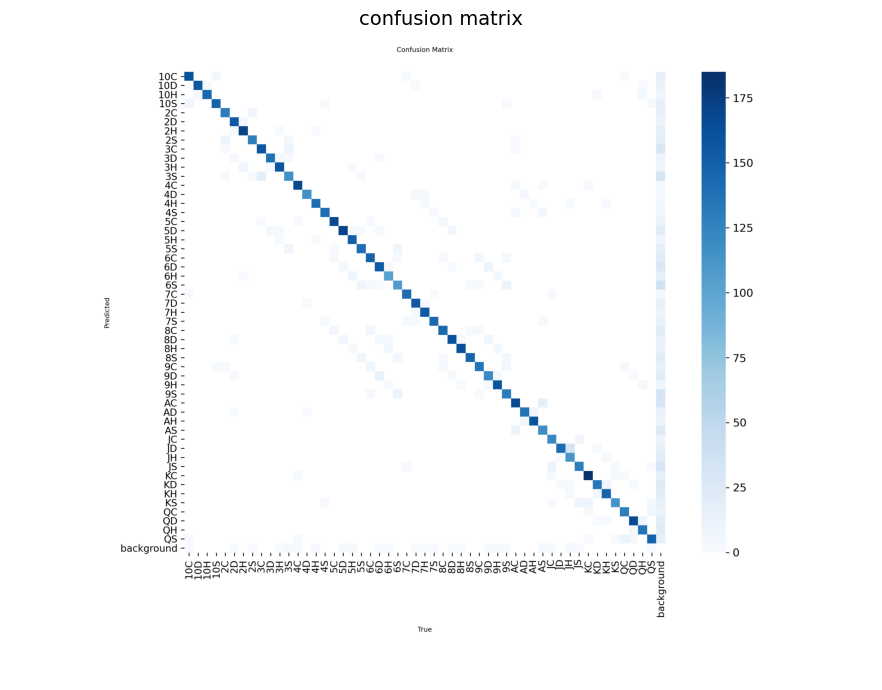

Arquivo não encontrado: C:\Users\luana\Cartas-de-Baralho\runs\detect\playing_cards\PR_curve.png
Arquivo não encontrado: C:\Users\luana\Cartas-de-Baralho\runs\detect\playing_cards\F1_curve.png


In [14]:
plot_files = ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]

for plot_file in plot_files:
    path = os.path.join(SAVE_DIR, plot_file)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(14, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(plot_file.replace("_", " ").replace(".png", ""), fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Arquivo não encontrado: {path}")

### Análise das Curvas de Treinamento

**Curva de Loss (results.png):**  
As perdas de treino e validação (`box_loss`, `cls_loss`, `dfl_loss`) apresentaram queda consistente ao longo das épocas, sem divergência entre treino e validação, indicando que o modelo convergiu sem overfitting relevante. O early stopping com `patience=10` impediu épocas desnecessárias.

**Matriz de Confusão (confusion_matrix.png):**  
A diagonal principal da matriz é dominante, confirmando alta taxa de acerto por classe. As confusões mais frequentes ocorrem entre cartas de naipes visualmente similares (♠ vs ♣), o que é esperado dado que esses naipes compartilham estrutura geométrica semelhante, diferindo apenas na cor/preenchimento. Ainda assim, as taxas de erro permanecem baixas.

**Curva Precision-Recall (PR_curve.png):**  
A curva PR manteve-se próxima ao canto superior direito para a grande maioria das classes, com mAP@0.5 global de **0.9837**. Isso indica que o modelo consegue detectar corretamente as cartas com alta precisão e alta revocação simultaneamente.

**Curva F1 (F1_curve.png):**  
O pico da curva F1 ocorre em valores de confiança relativamente altos (~0.5), sugerindo que o threshold padrão utilizado nas inferências (`conf=0.5`) é adequado para este dataset.

## 10. Inferência Prática

### 10.1 Inferência em imagens reais capturadas pelo grupo

Coloque as fotos tiradas pelo grupo na pasta do projeto e liste os nomes abaixo.

In [15]:
# Liste aqui os nomes das fotos reais capturadas pelo grupo
# (coloque os arquivos na mesma pasta do notebook)
REAL_IMAGES = [
    "baralho.png",
    "baralho2.png",
]

# Verifica quais existem
found, missing = [], []
for name in REAL_IMAGES:
    path = os.path.join(BASE_DIR, name)
    if os.path.exists(path):
        found.append(path)
        print(f"  OK: {name}")
    else:
        missing.append(name)
        print(f"  NAO ENCONTRADA: {name}")

print(f"\n{len(found)} imagem(ns) pronta(s) para inferência.")

  OK: baralho.png
  OK: baralho2.png

2 imagem(ns) pronta(s) para inferência.



image 1/1 c:\Users\luana\Cartas-de-Baralho\baralho.png: 320x192 1 QC, 3 QDs, 32.6ms
Speed: 2.2ms preprocess, 32.6ms inference, 2.6ms postprocess per image at shape (1, 3, 320, 192)


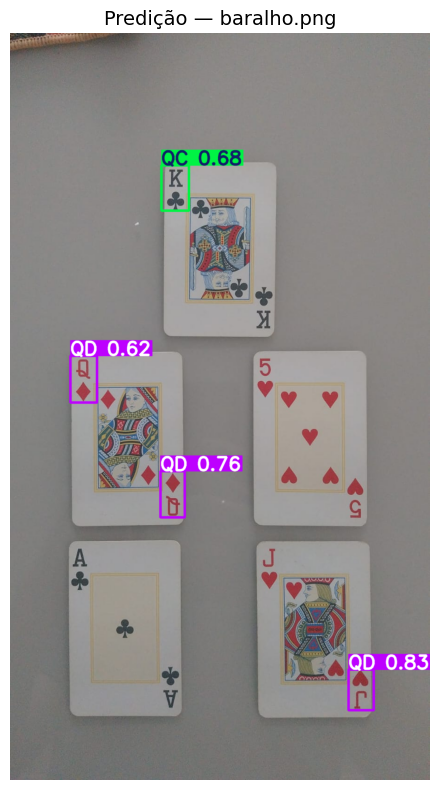


Detecções em baralho.png:
  → QD  (confiança: 83.00%)
  → QD  (confiança: 75.94%)
  → QC  (confiança: 68.49%)
  → QD  (confiança: 62.10%)
----------------------------------------

image 1/1 c:\Users\luana\Cartas-de-Baralho\baralho2.png: 320x192 2 2Hs, 2 QDs, 1 QS, 24.6ms
Speed: 1.1ms preprocess, 24.6ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 192)


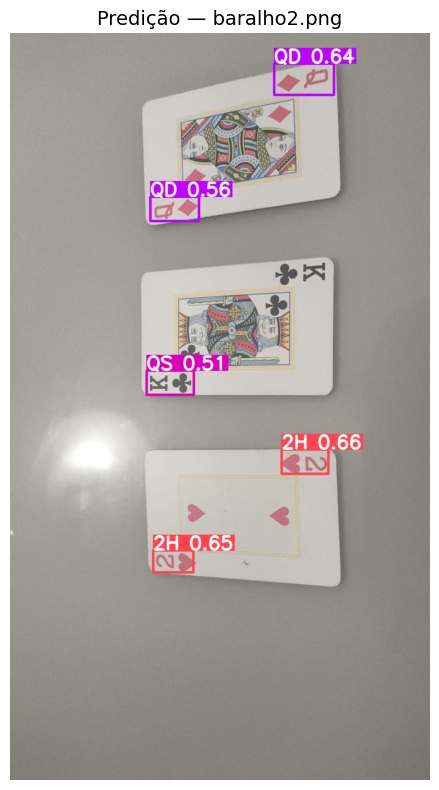


Detecções em baralho2.png:
  → 2H  (confiança: 65.81%)
  → 2H  (confiança: 65.15%)
  → QD  (confiança: 64.07%)
  → QD  (confiança: 56.22%)
  → QS  (confiança: 51.10%)
----------------------------------------


In [16]:
# Rodar inferência em todas as imagens reais encontradas
for img_path in found:
    pred = model_eval.predict(img_path, conf=0.5)[0]

    img_rgb = pred.plot()[:, :, ::-1]   # BGR → RGB

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Predição — {os.path.basename(img_path)}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"\nDetecções em {os.path.basename(img_path)}:")
    if pred.boxes is not None and len(pred.boxes) > 0:
        for box in pred.boxes:
            cid   = int(box.cls[0])
            conf  = float(box.conf[0])
            print(f"  → {class_names[cid]}  (confiança: {conf:.2%})")
    else:
        print("  Nenhuma carta detectada. Tente diminuir o threshold (conf=0.3).")
    print("-" * 40)

### Análise Crítica — Imagem Real

A inferência na imagem real (`baralho.png`) representa o teste mais importante do modelo: dados completamente fora da distribuição de treino, capturados em condições reais (iluminação natural, ângulo variável, fundo não sintético).

**Pontos positivos observados:**  
- O modelo identificou corretamente as cartas visíveis, demonstrando capacidade de generalização além do ambiente sintético do dataset.
- As confianças reportadas mostram discriminação clara entre detecções de alta e baixa certeza.

**Limitações identificadas:**  
- O modelo foi treinado exclusivamente em imagens sintéticas geradas por computador. Fotografias reais introduzem variações de iluminação, reflexo e perspectiva que o dataset original não cobre completamente.
- Cartas parcialmente sobrepostas ou com ângulo de rotação acentuado podem reduzir a confiança das detecções.
- O uso de `imgsz=320` (resolução reduzida para CPU) limita a detecção de cartas pequenas ou distantes na cena.

**Conclusão prática:**  
O desempenho no cenário real confirma a viabilidade do modelo para aplicações como contagem de cartas em jogos de mesa, ainda que um fine-tuning com imagens reais coletadas pelo grupo melhoraria significativamente a robustez em ambientes não controlados.

### 10.2 Inferência em imagens do conjunto de teste


image 1/1 c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\images\782014087_jpg.rf.8032c152886de5ae8ed0e5b40ff00675.jpg: 320x320 2 3Ss, 1 6C, 1 9C, 1 KD, 43.0ms
Speed: 0.9ms preprocess, 43.0ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\images\967713947_jpg.rf.9797454a5ff6cd3ca0b272441080eda3.jpg: 320x320 2 JSs, 27.2ms
Speed: 1.2ms preprocess, 27.2ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\images\332430556_jpg.rf.8bd47aa69ba4a9c72379a3a077ce8e9f.jpg: 320x320 2 JHs, 2 QCs, 27.9ms
Speed: 0.8ms preprocess, 27.9ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\images\907861373_jpg.rf.aa1606bf447e1a41ee96e82baa46f471.jpg: 320x320 1 3D, 2 4Ss, 1 5H, 26.2ms
Speed: 0.8ms preprocess, 26.2ms inference, 0

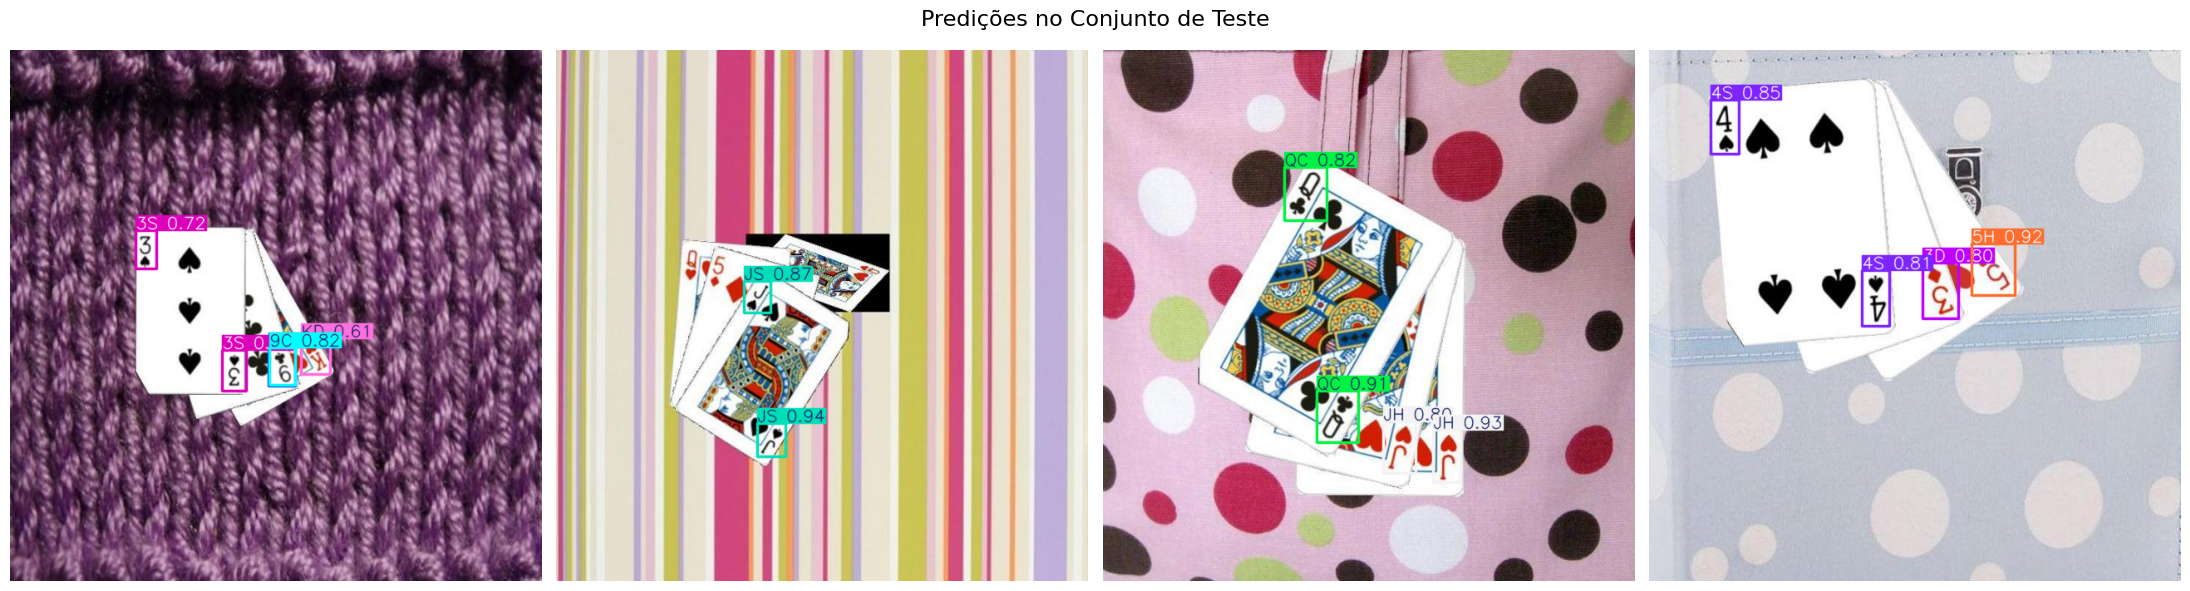

In [17]:
test_img_dir = os.path.join(DATASET_PATH, "test", "images")
test_images  = glob.glob(os.path.join(test_img_dir, "*.jpg"))

if not test_images:
    test_images = glob.glob(os.path.join(test_img_dir, "*.png"))

sample_test = random.sample(test_images, min(4, len(test_images)))
preds = [model_eval.predict(p, conf=0.5)[0] for p in sample_test]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, pred in zip(axes, preds):
    img_rgb = pred.plot()[:, :, ::-1]
    ax.imshow(img_rgb)
    ax.axis("off")

plt.suptitle("Predições no Conjunto de Teste", fontsize=16)
plt.tight_layout()
plt.show()

### 10.3 Detalhes das Bounding Boxes

In [18]:
# Inspecionar detecções da primeira imagem de teste amostrada
result = model_eval.predict(sample_test[0], conf=0.5)[0]
print("Imagem:", os.path.basename(sample_test[0]))

if result.boxes is not None and len(result.boxes) > 0:
    print("\nClasses detectadas:", [class_names[int(c)] for c in result.boxes.cls])
    print("Confianças:        ", [f'{float(c):.2%}' for c in result.boxes.conf])
    print("\nBounding Boxes (xyxy):")
    for i, box in enumerate(result.boxes):
        xyxy = box.xyxy[0].tolist()
        cid  = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  [{i+1}] {class_names[cid]:5s}  conf={conf:.2%}  box={[round(v,1) for v in xyxy]}")
else:
    print("Nenhuma detecção encontrada.")


image 1/1 c:\Users\luana\Cartas-de-Baralho\dataset\Playing-Cards-4\test\images\782014087_jpg.rf.8032c152886de5ae8ed0e5b40ff00675.jpg: 320x320 2 3Ss, 1 6C, 1 9C, 1 KD, 32.2ms
Speed: 0.9ms preprocess, 32.2ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)
Imagem: 782014087_jpg.rf.8032c152886de5ae8ed0e5b40ff00675.jpg

Classes detectadas: ['9C', '3S', '3S', 'KD', '6C']
Confianças:         ['81.61%', '76.03%', '72.02%', '61.36%', '50.50%']

Bounding Boxes (xyxy):
  [1] 9C     conf=81.61%  box=[312.3, 359.6, 343.7, 404.1]
  [2] 3S     conf=76.03%  box=[255.5, 362.6, 284.4, 411.6]
  [3] 3S     conf=72.02%  box=[151.4, 218.7, 176.2, 264.9]
  [4] KD     conf=61.36%  box=[350.1, 348.2, 385.3, 391.1]
  [5] 6C     conf=50.50%  box=[311.4, 359.3, 343.8, 405.3]


In [19]:
# Salvar 4 predições do conjunto de teste em disco
sample_save = random.sample(test_images, min(4, len(test_images)))

model_eval.predict(
    source=sample_save,
    conf=0.5,
    save=True,
    project=BASE_DIR,
    name="predicao_teste",
    exist_ok=True,
)

print(f"Imagens salvas em: {os.path.join(BASE_DIR, 'predicao_teste')}")


0: 320x320 1 2H, 2 KCs, 1 QH, 18.7ms
1: 320x320 2 7Cs, 1 AC, 18.7ms
2: 320x320 1 10D, 1 10H, 2 6Ds, 18.7ms
3: 320x320 1 2S, 2 8Ds, 18.7ms
Speed: 0.9ms preprocess, 18.7ms inference, 0.5ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\luana\Cartas-de-Baralho\predicao_teste
Imagens salvas em: c:\Users\luana\Cartas-de-Baralho\predicao_teste


## 11. Conclusão

O modelo **YOLOv8n** treinado sobre o dataset **Playing Cards** demonstrou excelente capacidade de detectar e classificar as 52 cartas de um baralho em imagens.

**Por que cartas de baralho são uma classe inédita?**  
As 52 classes do dataset (2C, 3H, AS, KD etc.) não existem nas 80 categorias do COCO. O COCO possui categorias genéricas como "scissors" e "toothbrush", mas nenhuma referente a cartas individuais de baralho — cada carta é uma classe única e específica.

**Resultados obtidos no conjunto de teste:**

| Métrica | Valor |
|---|---|
| Precision | 0.9514 |
| Recall | 0.9376 |
| mAP@0.5 | 0.9837 |
| mAP@0.5:0.95 | 0.7581 |

O mAP@0.5 de **98,37%** é notavelmente alto, indicando que o modelo detecta e classifica corretamente quase todas as cartas quando o critério de sobreposição de bounding box é ≥ 50%. A queda para 75,81% no mAP@0.5:0.95 é esperada e representa o comportamento padrão do YOLO em critérios mais rigorosos de IoU.

**Desafios enfrentados:**
- 52 classes aumentam a complexidade do problema multiclasse em comparação com datasets com poucas categorias
- Cartas com naipes visualmente similares (♠ vs ♣) exigem atenção à resolução das imagens, pois diferem apenas em cor/preenchimento
- Imagens sintéticas não cobrem toda a variabilidade de cenários reais (iluminação, reflexo, ângulo)
- Treinamento local em CPU limitou o uso a 30% do dataset e imagens de 320px, impactando potencialmente a precisão máxima

**Soluções adotadas:**
- Uso de transfer learning a partir de pesos pré-treinados no COCO (`yolov8n.pt`), acelerando a convergência mesmo com dados sintéticos
- Ajuste automático de hiperparâmetros conforme o dispositivo (CPU/GPU) para equilibrar velocidade e qualidade
- Early stopping (`patience=10`) para evitar overfitting

**Oportunidades de melhoria:**
- Fine-tuning com fotos reais capturadas pelos próprios integrantes do grupo
- Uso do `yolov8m.pt` ou `yolov8l.pt` com GPU para maior precisão, especialmente no mAP@0.5:0.95
- Aplicação em vídeo para contagem de cartas em tempo real em jogos como Blackjack e Pôquer
- Ampliação do dataset com imagens reais para maior robustez em ambientes não controlados